In [24]:
from swo_lanczos_2023_09_08 import output_dir
from misc_utils import read_jsonl_to_df
import seaborn as sns
import matplotlib.pyplot as plt

In [25]:
overlaps_df = read_jsonl_to_df(output_dir / "overlaps.jsonl")
losses_df = read_jsonl_to_df(output_dir / "losses.jsonl")

In [26]:
losses_df

,iteration,epoch,loss,run,mode,n_samples,lattice,energy_baseline
0,0,0,12.081117,0,power,5000,KagomeLattice2x5,NaN
1,0,1,0.535841,0,power,5000,KagomeLattice2x5,NaN
2,0,2,0.537669,0,power,5000,KagomeLattice2x5,NaN
3,0,3,0.523367,0,power,5000,KagomeLattice2x5,NaN
4,0,4,0.513331,0,power,5000,KagomeLattice2x5,NaN
...,...,...,...,...,...,...,...,...
100714,419,14,0.000648,0,power,5000,KagomeLattice2x3,250.0
100715,419,15,0.000335,0,power,5000,KagomeLattice2x3,250.0
100716,419,16,0.000275,0,power,5000,KagomeLattice2x3,250.0
100717,419,17,0.000304,0,power,5000,KagomeLattice2x3,250.0


In [27]:
# sns.relplot(
#     losses_df.query("iteration > 0").assign(
#         global_epoch=lambda df: df["epoch"] + df["iteration"] * (df["epoch"].max() + 1)
#     ),
#     x="global_epoch",
#     y="loss",
#     kind="line",
#     aspect=2,
#     hue='mode',
#     row='lattice',
# )

In [28]:
def to_cat(col):
    def wrapper(df):
        df = df.copy()
        df[col] = df[col].astype("category")
        return df
    return wrapper

In [29]:
overlaps_df

,iteration,initial_ground_state_overlap_train,initial_ground_state_overlap_test,target_ground_state_overlap_train,new_ground_state_overlap_train,new_ground_state_overlap_test,run,mode,alpha,n_samples,lattice,energy_baseline
0,0,0.169192,0.180537,0.239985,0.238659,0.241433,0,power,NaN,5000,KagomeLattice2x5,NaN
1,1,0.294694,0.261315,0.383670,0.382243,0.324993,0,power,NaN,5000,KagomeLattice2x5,NaN
2,2,0.393670,0.321730,0.483922,0.482819,0.372905,0,power,NaN,5000,KagomeLattice2x5,NaN
3,3,0.451474,0.380128,0.544825,0.543151,0.429491,0,power,NaN,5000,KagomeLattice2x5,NaN
4,4,0.506271,0.423209,0.589980,0.584798,0.458261,0,power,NaN,5000,KagomeLattice2x5,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1000,414,0.984025,0.919164,0.984131,0.984132,0.918418,0,power,NaN,5000,KagomeLattice2x3,250.0
1001,415,0.984575,0.920108,0.984655,0.984721,0.920028,0,power,NaN,5000,KagomeLattice2x3,250.0
1002,416,0.984303,0.925692,0.984402,0.984494,0.925405,0,power,NaN,5000,KagomeLattice2x3,250.0
1003,417,0.984508,0.916824,0.984598,0.984577,0.915915,0,power,NaN,5000,KagomeLattice2x3,250.0


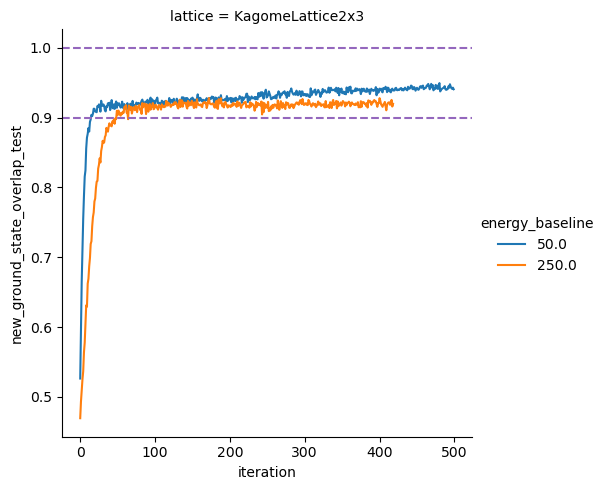

In [30]:
sns.relplot(
    overlaps_df.query("lattice == 'KagomeLattice2x3'").pipe(to_cat("energy_baseline")),
    x="iteration",
    y="new_ground_state_overlap_test",
    hue="energy_baseline",
    kind="line",
    row="lattice",
)
plt.axhline(1, ls='--', color='C4')
plt.axhline(0.9, ls='--', color='C4')


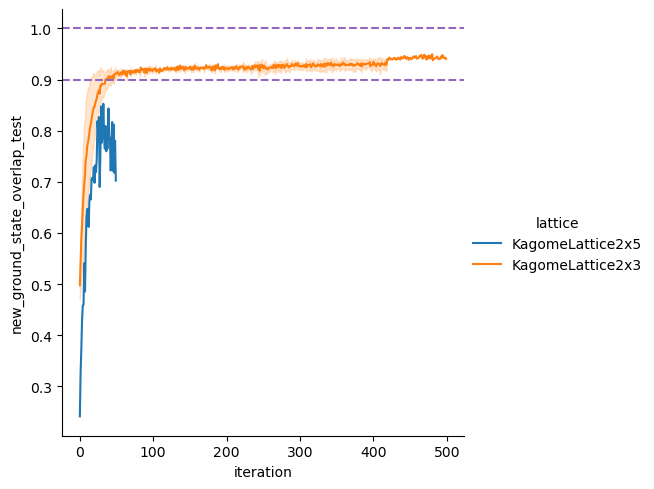

In [31]:
sns.relplot(
    overlaps_df.query("mode == 'power'"),
    x="iteration",
    y="new_ground_state_overlap_test",
    hue="lattice",
    kind="line",
)
plt.axhline(1, ls='--', color='C4')
plt.axhline(0.9, ls='--', color='C4')
